In [18]:
import boto3
import os
from dotenv import load_dotenv
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import io

## Manually download dataset
- Download the dataset via kaggle cli. This save datasets into smb
```bash
kaggle datasets download -d crowww/a-large-scale-fish-dataset -p /Volumes/kaggle/
ls /Volumes/kaggle/
```

```bash
unzip /Volumes/kaggle/a-large-scale-fish-dataset.zip -d /Volumes/kaggle/
```

In [2]:
load_dotenv(Path("../.env"))

s3 = boto3.client(
    "s3",
    endpoint_url=os.getenv("AISTOR_ENDPOINT"),
    aws_access_key_id=os.getenv("AISTOR_ACCESS_KEY"),
    aws_secret_access_key=os.getenv("AISTOR_SECRET_KEY")
)

In [3]:
# Test connection
buckets = s3.list_buckets()
print(buckets['Buckets'])

[{'Name': 'fish-classifier', 'CreationDate': datetime.datetime(2026, 5, 25, 20, 42, 34, 360000, tzinfo=tzutc())}]


In [6]:
DATASET_PATH = Path("/Volumes/kaggle/Fish_Dataset/Fish_Dataset")

In [8]:
# Check already uploaded
uploaded = set()
paginator = s3.get_paginator('list_objects_v2')
for page in paginator.paginate(Bucket="fish-classifier", Prefix="raw/"):
    for obj in page.get('Contents', []):
        uploaded.add(obj['Key'])

print(f"Already uploaded: {len(uploaded)} files")

Already uploaded: 0 files


In [10]:
# Upload
uploaded_count = 0
for fish_class in DATASET_PATH.iterdir():
    if fish_class.is_dir():
        img_folder = fish_class / fish_class.name
        if img_folder.exists():
            for img in img_folder.iterdir():
                if img.is_file() and img.suffix == '.png':
                    key = f"raw/{fish_class.name}/{img.name}"
                    if key not in uploaded:
                        s3.upload_file(str(img), "fish-classifier", key)
                        uploaded_count += 1
                        print(f"Uploaded: {key}")

print(f"Total new uploads: {uploaded_count}")

Uploaded: raw/Hourse Mackerel/00299.png
Uploaded: raw/Hourse Mackerel/00248.png
Uploaded: raw/Hourse Mackerel/00629.png
Uploaded: raw/Hourse Mackerel/00310.png
Uploaded: raw/Hourse Mackerel/00771.png
Uploaded: raw/Hourse Mackerel/00007.png
Uploaded: raw/Hourse Mackerel/00466.png
Uploaded: raw/Hourse Mackerel/00814.png
Uploaded: raw/Hourse Mackerel/00684.png
Uploaded: raw/Hourse Mackerel/00123.png
Uploaded: raw/Hourse Mackerel/00930.png
Uploaded: raw/Hourse Mackerel/00542.png
Uploaded: raw/Hourse Mackerel/00234.png
Uploaded: raw/Hourse Mackerel/00593.png
Uploaded: raw/Hourse Mackerel/00655.png
Uploaded: raw/Hourse Mackerel/00868.png
Uploaded: raw/Hourse Mackerel/00124.png
Uploaded: raw/Hourse Mackerel/00683.png
Uploaded: raw/Hourse Mackerel/00545.png
Uploaded: raw/Hourse Mackerel/00937.png
Uploaded: raw/Hourse Mackerel/00594.png
Uploaded: raw/Hourse Mackerel/00233.png
Uploaded: raw/Hourse Mackerel/00652.png
Uploaded: raw/Hourse Mackerel/00158.png
Uploaded: raw/Hourse Mackerel/00539.png


KeyboardInterrupt: 

In [11]:
# Check for uploaded files
paginator = s3.get_paginator('list_objects_v2')
class_counts = {}

for page in paginator.paginate(Bucket="fish-classifier", Prefix="raw/"):
    for obj in page.get('Contents', []):
        class_name = obj['Key'].split('/')[1]
        class_counts[class_name] = class_counts.get(class_name, 0) + 1

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")

Black Sea Sprat: 1000 images
Gilt-Head Bream: 1000 images
Hourse Mackerel: 1000 images
Red Mullet: 1000 images
Red Sea Bream: 1000 images
Sea Bass: 1000 images
Shrimp: 1000 images
Striped Red Mullet: 1000 images
Trout: 1000 images


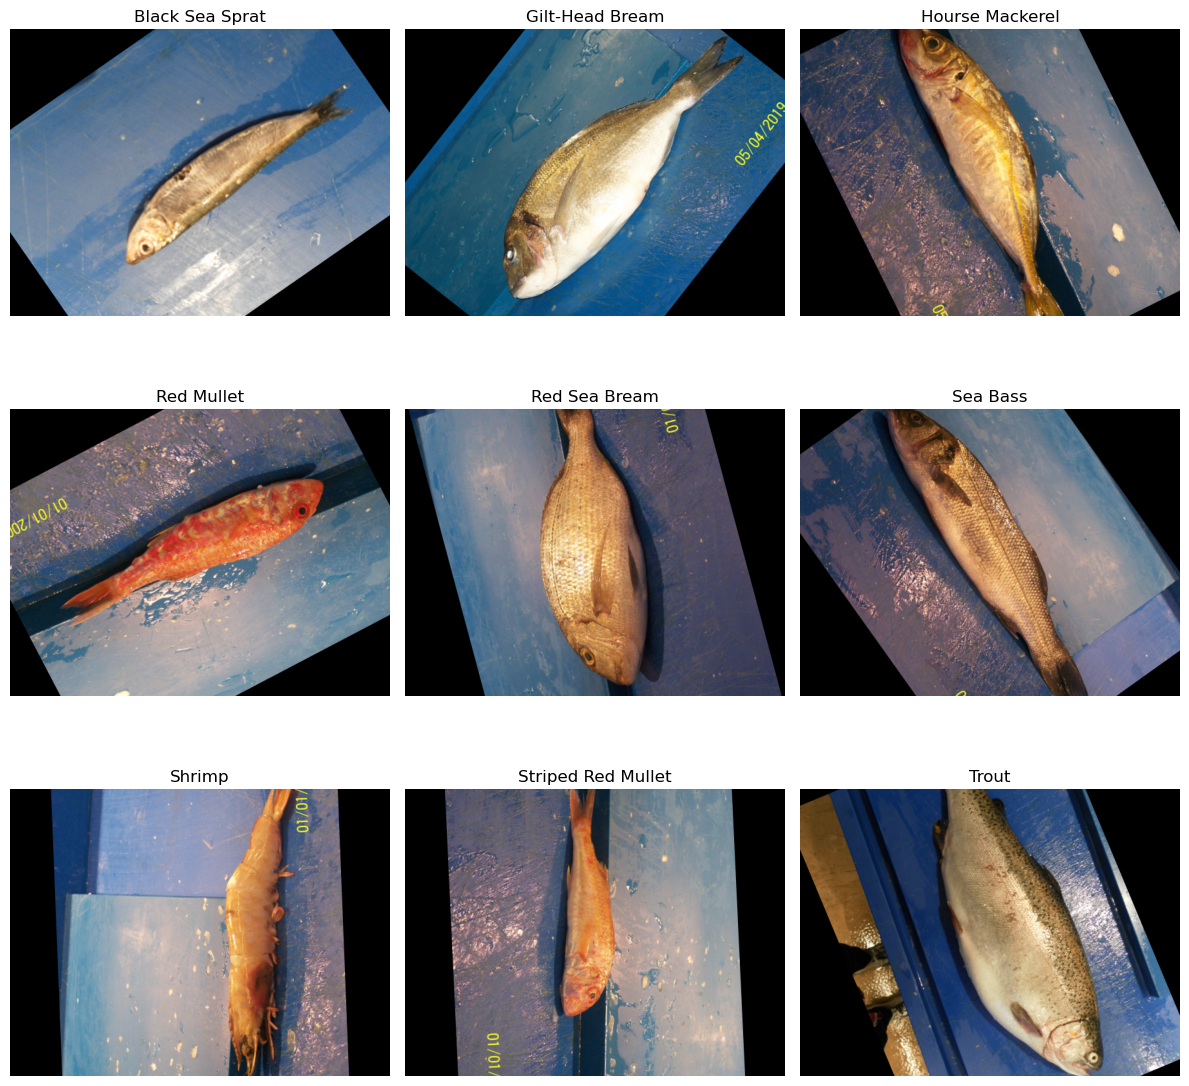

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for idx, class_name in enumerate(sorted(class_counts.keys())):
    # Get first image of each class
    response = s3.get_object(Bucket="fish-classifier", Key=f"raw/{class_name}/00001.png")
    img = Image.open(io.BytesIO(response['Body'].read()))
    
    axes[idx].imshow(img)
    axes[idx].set_title(class_name)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig("../outputs/class_samples.png")
plt.show()